# SBV2 05 - Local VLM Extraction (PaddleOCR-VL)

This notebook runs PaddleOCR-VL-0.9B on the same eight documents the OCR baseline used in Notebook 04, then produces the headline comparison figure for the horizon scan: per-source region count and recovered text volume, baseline vs document VLM.

Default run performs PaddleOCR-VL prediction on the full eight-document NB04 OCR sample, then builds the baseline-vs-VL comparison chart. Set `MAX_DOCS = 1` for a quick smoke run, or `INIT_ONLY = True` when you only want a model-load check without prediction. Inference runs locally on CPU via the `native` backend (paddlepaddle in this environment is CPU-only).

## Contract

Inputs:

- `data/interim/sandbox_v2/manifests/sbv2_03_document_manifest.csv`
- `data/interim/sandbox_v2/manifests/sbv2_04_ocr_sample_manifest.csv`
- `outputs/sandbox_v2/audit_tables/sbv2_04_ocr_document_summary.csv`
- `models/paddleocr-vl/` and `models/paddleocr-vl/PP-DocLayoutV2/`

Outputs:

- `data/interim/sandbox_v2/manifests/sbv2_05_vl_sample_manifest.csv`
- `data/interim/sandbox_v2/vl_outputs/sbv2_05_vl_document_outputs.jsonl`
- `data/interim/sandbox_v2/vl_outputs/sbv2_05_vl_text_regions.csv`
- `data/interim/sandbox_v2/vl_outputs/markdown/<unified_document_id>.md` per ok document
- VL audit tables under `outputs/sandbox_v2/audit_tables/` (document summary, source summary, baseline-vs-VL comparison, failures, summary JSON)
- VL overlay contact sheet and the baseline-vs-VL comparison figure under `outputs/figures/sandbox_v2/`

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "sandbox_v2").exists():
    candidates = [parent for parent in ROOT.parents if (parent / "sandbox_v2").exists()]
    if candidates:
        ROOT = candidates[0]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

CACHE_DIR = Path(os.environ.get("MENUFORGE_CACHE_HOME", ROOT / ".cache")).resolve()
for env_name, relative_path in {
    "XDG_CACHE_HOME": "",
    "PADDLE_PDX_CACHE_HOME": "paddlex",
    "MPLCONFIGDIR": "matplotlib",
    "JUPYTER_CONFIG_DIR": "jupyter_config",
    "JUPYTER_DATA_DIR": "jupyter_data",
    "JUPYTER_RUNTIME_DIR": "jupyter_runtime",
    "IPYTHONDIR": "ipython",
    "HF_HOME": "huggingface",
    "TORCH_HOME": "torch",
}.items():
    target = (CACHE_DIR / relative_path) if relative_path else CACHE_DIR
    target.mkdir(parents=True, exist_ok=True)
    os.environ.setdefault(env_name, str(target))
os.environ.setdefault("PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK", "True")

print({"ROOT": str(ROOT), "CACHE_DIR": str(CACHE_DIR)})

{'ROOT': '/home/endy/menuforge', 'CACHE_DIR': '/home/endy/menuforge/.cache'}


In [2]:
# Default: run the same eight-document sample used by Notebook 04.
# Set MAX_DOCS = 1 for a quick smoke run, or INIT_ONLY = True for a model-load check.
RUN_VL = True
INIT_ONLY = False
PREFERRED_SOURCE = ""
MAX_PER_SOURCE = 1
MAX_DOCS = 8
DEBUG_FIRST = True

print({
    "RUN_VL": RUN_VL,
    "INIT_ONLY": INIT_ONLY,
    "PREFERRED_SOURCE": PREFERRED_SOURCE,
    "MAX_PER_SOURCE": MAX_PER_SOURCE,
    "MAX_DOCS": MAX_DOCS,
    "DEBUG_FIRST": DEBUG_FIRST,
})

{'RUN_VL': True, 'INIT_ONLY': False, 'PREFERRED_SOURCE': '', 'MAX_PER_SOURCE': 1, 'MAX_DOCS': 8, 'DEBUG_FIRST': True}


### Preflight: confirm NB04 baseline + local model exist

If any of these are missing, do not run the engine — fix the inputs first.

In [3]:
preflight = {
    "sbv2_03_manifest": (ROOT / "data/interim/sandbox_v2/manifests/sbv2_03_document_manifest.csv").exists(),
    "sbv2_04_ocr_sample": (ROOT / "data/interim/sandbox_v2/manifests/sbv2_04_ocr_sample_manifest.csv").exists(),
    "sbv2_04_ocr_doc_summary": (ROOT / "outputs/sandbox_v2/audit_tables/sbv2_04_ocr_document_summary.csv").exists(),
    "paddleocr_vl_weights": (ROOT / "models/paddleocr-vl/model.safetensors").exists(),
    "paddleocr_vl_config": (ROOT / "models/paddleocr-vl/config.json").exists(),
    "pp_doclayout_local_dir": (ROOT / "models/paddleocr-vl/PP-DocLayoutV2").exists(),
}
for name, ok in preflight.items():
    print(f"  {'OK ' if ok else 'MISS'}  {name}")
missing = [n for n, ok in preflight.items() if not ok]
if missing:
    raise FileNotFoundError(f"Preflight failed; missing: {missing}")

  OK   sbv2_03_manifest
  OK   sbv2_04_ocr_sample
  OK   sbv2_04_ocr_doc_summary
  OK   paddleocr_vl_weights
  OK   paddleocr_vl_config
  OK   pp_doclayout_local_dir


In [4]:
from sandbox_v2.local_vlm_extraction import write_outputs

summary_path = ROOT / "outputs" / "sandbox_v2" / "audit_tables" / "sbv2_05_vl_summary.json"
if RUN_VL:
    summary = write_outputs(
        max_per_source=MAX_PER_SOURCE,
        max_docs=MAX_DOCS,
        debug_first=DEBUG_FIRST,
        init_only=INIT_ONLY,
        preferred_source=PREFERRED_SOURCE,
    )
elif summary_path.exists():
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
else:
    raise FileNotFoundError("RUN_VL is false and no previous SBV2 05 summary exists.")

print(json.dumps({
    "vl_engine": summary.get("vl_engine"),
    "engine_status": summary.get("engine_status"),
    "engine_message": summary.get("engine_message"),
    "sample_rows": summary.get("sample_rows"),
    "init_only": summary.get("init_only"),
    "preferred_source": summary.get("preferred_source"),
    "ok_rows": summary.get("ok_rows"),
    "failure_rows": summary.get("failure_rows"),
    "vl_region_rows": summary.get("vl_region_rows"),
    "mean_runtime_seconds": summary.get("mean_runtime_seconds"),
    "comparison_figure": summary.get("comparison_figure"),
    "overlay_contact_sheet": summary.get("overlay_contact_sheet"),
}, indent=2))

/home/endy/menuforge/.venv/lib/python3.11/site-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-DocLayoutV3', '/home/endy/menuforge/models/paddleocr-vl/PP-DocLayoutV2', None)
Creating model: ('PaddleOCR-VL-0.9B', '/home/endy/menuforge/models/paddleocr-vl', None)
Bucketed engine_config has no entry for resolved engine 'paddle_dynamic'; using an empty config for that engine.
Loading configuration file /home/endy/menuforge/models/paddleocr-vl/config.json
Loading weights file /home/endy/menuforge/models/paddleocr-vl/model.safetensors
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA 

{
  "vl_engine": "paddleocr_vl_0.9b_native_cpu",
  "engine_status": "ready",
  "engine_message": "",
  "sample_rows": 8,
  "init_only": false,
  "preferred_source": "",
  "ok_rows": 8,
  "failure_rows": 0,
  "vl_region_rows": 8,
  "mean_runtime_seconds": 52.339,
  "comparison_figure": "outputs/figures/sandbox_v2/sbv2_05_baseline_vs_vl_comparison.png",
  "overlay_contact_sheet": "outputs/figures/sandbox_v2/sbv2_05_vl_overlay_contact_sheet.jpg"
}


### Debug: engine and first-payload structure

If this shows `engine_init_status: ready`, the local PaddleOCR-VL runtime is fixed and prediction was intentionally skipped by `INIT_ONLY = True`. Set `INIT_ONLY = False` in the controls cell to run one CPU prediction.

If this shows `engine_init_error`, fix the runtime before trusting any comparison figure. If prediction runs and `payload_top_keys` is present but missing expected keys (`parsing_res_list`, `markdown`, `layout_det_res`), widen the helper's `_walk_for_blocks`.

In [5]:
debug = summary.get("debug_first_payload")
if debug:
    if debug.get("engine_init_status"):
        display(Markdown("**Engine initialization check:**"))
        print(json.dumps(debug, indent=2, default=str)[:2500])
    else:
        display(Markdown("**First document inspected:**"))
        print(json.dumps(debug.get("row", {}), indent=2))
        display(Markdown("**Top-level keys in the VL payload:**"))
        print(debug.get("payload_top_keys"))
        display(Markdown("**Shallow payload excerpt (truncated):**"))
        print(json.dumps(debug.get("payload_excerpt", {}), indent=2, default=str)[:2000])
else:
    display(Markdown("_No debug payload. Check `engine_message` in the run summary._"))

**First document inspected:**

{
  "unified_document_id": "sroie__sroie_00000",
  "source_id": "sroie",
  "document_id": "sroie_00000",
  "image_path": "data/raw/sandbox_v2/sroie/images/sroie_00000.jpg"
}


**Top-level keys in the VL payload:**

['input_path', 'page_index', 'page_count', 'width', 'height', 'model_settings', 'parsing_res_list']


**Shallow payload excerpt (truncated):**

{
  "input_path": "/home/endy/menuforge/data/raw/sandbox_v2/sroie/images/sroie_00000.jpg",
  "page_index": null,
  "page_count": null,
  "width": 463,
  "height": 1013,
  "model_settings": {
    "use_doc_preprocessor": false,
    "use_layout_detection": false,
    "use_chart_recognition": false,
    "use_seal_recognition": false,
    "use_ocr_for_image_block": false,
    "format_block_content": false,
    "merge_layout_blocks": true,
    "markdown_ignore_labels": [
      "<str>",
      "<str>",
      "<str>"
    ]
  },
  "parsing_res_list": [
    {
      "block_label": "<str>",
      "block_content": "<str>",
      "block_bbox": "<list>",
      "block_id": "<int>",
      "block_order": "<int>",
      "group_id": "<int>"
    }
  ]
}


In [6]:
def _safe_read_csv(path, **kw):
    try:
        return pd.read_csv(path, **kw)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()

doc_summary = _safe_read_csv(ROOT / summary["document_summary_csv"])
source_summary = _safe_read_csv(ROOT / summary["source_summary_csv"]) if summary.get("source_summary_csv") else pd.DataFrame()
failures = _safe_read_csv(ROOT / summary["failures_csv"])
regions = _safe_read_csv(ROOT / summary["text_regions_csv"], low_memory=False)

comparison = pd.DataFrame()
if summary.get("comparison_csv"):
    comparison = _safe_read_csv(ROOT / summary["comparison_csv"])

display(Markdown("### Source Summary (PaddleOCR-VL)"))
display(source_summary)

display(Markdown("### Document Summary (PaddleOCR-VL)"))
display(doc_summary)

display(Markdown("### VL Region Sample (first 20 rows)"))
display(regions.head(20))

if comparison.empty:
    display(Markdown("### Baseline vs VL Comparison\n\n_(No comparison produced \u2014 check that NB04 doc summary exists and the VL engine succeeded.)_"))
else:
    display(Markdown("### Baseline vs VL Comparison (per document)"))
    display(comparison)

if failures.empty:
    display(Markdown("### Failures\n\nNo VL failures in this run."))
else:
    display(Markdown("### Failures"))
    display(failures)

### Source Summary (PaddleOCR-VL)

,source_id,documents,ok_documents,total_regions,mean_regions,mean_runtime_seconds,mean_text_char_count,mean_price_like_count
0,cord,1,1,1,1.0,54.313,440.0,17.0
1,funsd,1,1,1,1.0,50.101,839.0,0.0
2,nypl,1,1,1,1.0,54.404,20.0,0.0
3,nypl_expanded,1,1,1,1.0,54.452,20.0,0.0
4,sroie,1,1,1,1.0,53.898,1.0,0.0
5,synthetic_menu_concepts,1,1,1,1.0,45.459,555.0,9.0
6,wikimedia_commons_english_menus,1,1,1,1.0,52.965,38.0,0.0
7,wikimedia_english_menus,1,1,1,1.0,53.118,44.0,0.0


### Document Summary (PaddleOCR-VL)

,unified_document_id,source_id,document_id,dataset_family,task_family,evaluation_scope,image_path,vl_engine,vl_status,vl_runtime_seconds,vl_region_count,vl_text_char_count,vl_word_like_count,vl_price_like_count,vl_label_counts,markdown_path,vl_full_text_preview
0,sroie__sroie_00000,sroie,sroie_00000,receipt,receipt_kv_ocr,receipt_kv_ground_truth,data/raw/sandbox_v2/sroie/images/sroie_00000.jpg,paddleocr_vl_0.9b_native_cpu,ok,53.898,1,1,1,0,"{""ocr"": 1}",NaN,B
1,funsd__funsd_0,funsd,funsd_0,form,form_kv_ocr,form_kv_ground_truth,data/raw/sandbox_v2/funsd/images/funsd_0.jpg,paddleocr_vl_0.9b_native_cpu,ok,50.101,1,839,121,0,"{""ocr"": 1}",NaN,RAG QUALITY IMPROVEMENT SEGRETION/SOLUTION FOR...
2,nypl__nypl_page_45078,nypl,nypl_page_45078,menu,menu_ocr_extraction,menu_extraction_candidate,data/raw/nypl/images/45078.jpg,paddleocr_vl_0.9b_native_cpu,ok,54.404,1,20,3,0,"{""ocr"": 1}",NaN,Bacillata est Rerata
3,nypl_expanded__nypl_expanded_144,nypl_expanded,nypl_expanded_144,menu,menu_ocr_extraction,menu_extraction_candidate,data/raw/sandbox_v2/public_menu_sources/nypl_e...,paddleocr_vl_0.9b_native_cpu,ok,54.452,1,20,3,0,"{""ocr"": 1}",NaN,(Oyster cocktail 30)
4,synthetic_menu_concepts__synthetic_menu_concep...,synthetic_menu_concepts,synthetic_menu_concept_0000,menu,menu_ocr_extraction,menu_extraction_candidate,data/raw/sandbox_v2/synthetic_menu_concepts/im...,paddleocr_vl_0.9b_native_cpu,ok,45.459,1,555,82,9,"{""ocr"": 1}",NaN,Harbor & Hearth SEASONAL COASTAL PLATES SMALL ...
5,wikimedia_commons_english_menus__wikimedia_com...,wikimedia_commons_english_menus,wikimedia_commons_0000,menu,menu_ocr_extraction,ocr_layout_sidecar,data/raw/sandbox_v2/public_menu_sources/wikime...,paddleocr_vl_0.9b_native_cpu,ok,52.965,1,38,6,0,"{""ocr"": 1}",NaN,"New Orleans, THURSDAY, March 24, 1859."
6,wikimedia_english_menus__wikimedia_menu_000,wikimedia_english_menus,wikimedia_menu_000,menu,menu_ocr_extraction,ocr_layout_sidecar,data/raw/wikimedia_english_menus/Menu of Albin...,paddleocr_vl_0.9b_native_cpu,ok,53.118,1,44,8,0,"{""ocr"": 1}",NaN,S&P | Rank | Price (US$ per liter) | Price (
7,cord__cord_smoke_0000,cord,cord_smoke_0000,receipt,receipt_line_item_smoke,ocr_layout_sidecar,data/raw/sandbox_v2/smoke_sources/cord/cord_0.jpg,paddleocr_vl_0.9b_native_cpu,ok,54.313,1,440,109,17,"{""ocr"": 1}",NaN,"1 Nasi Campur Sali 75,000 1 Bob Bengali Nasi 1..."


### VL Region Sample (first 20 rows)

,unified_document_id,source_id,document_id,region_index,label,text,x_min,y_min,x_max,y_max
0,sroie__sroie_00000,sroie,sroie_00000,0,ocr,B,0.0,0.0,463.0,1013.0
1,funsd__funsd_0,funsd,funsd_0,0,ocr,RAG QUALITY IMPROVEMENT SEGRETION/SOLUTION FOR...,0.0,0.0,762.0,1000.0
2,nypl__nypl_page_45078,nypl,nypl_page_45078,0,ocr,Bacillata est Rerata,0.0,0.0,604.0,760.0
3,nypl_expanded__nypl_expanded_144,nypl_expanded,nypl_expanded_144,0,ocr,(Oyster cocktail 30),0.0,0.0,528.0,760.0
4,synthetic_menu_concepts__synthetic_menu_concep...,synthetic_menu_concepts,synthetic_menu_concept_0000,0,ocr,Harbor & Hearth\nSEASONAL COASTAL PLATES\nSMAL...,0.0,0.0,1500.0,1050.0
5,wikimedia_commons_english_menus__wikimedia_com...,wikimedia_commons_english_menus,wikimedia_commons_0000,0,ocr,"New Orleans, THURSDAY, March 24, 1859.",0.0,0.0,1375.0,1086.0
6,wikimedia_english_menus__wikimedia_menu_000,wikimedia_english_menus,wikimedia_menu_000,0,ocr,S&P | Rank | Price (US$ per liter) | Price (,0.0,0.0,8160.0,6144.0
7,cord__cord_smoke_0000,cord,cord_smoke_0000,0,ocr,"1 Nasi Campur Sali 75,000\n1 Bob Bengali Nasi ...",0.0,0.0,512.0,768.0


### Baseline vs VL Comparison (per document)

,unified_document_id,source_id,document_id,ocr_line_count,vl_region_count,region_count_lift,ocr_text_char_count,vl_text_char_count,text_char_lift,ocr_price_like_count,vl_price_like_count,price_count_lift,ocr_runtime_seconds,vl_runtime_seconds
0,sroie__sroie_00000,sroie,sroie_00000,45,1,-44,514,1,-513,8,0,-8,2.206,53.898
1,funsd__funsd_0,funsd,funsd_0,27,1,-26,937,839,-98,0,0,0,2.976,50.101
2,nypl__nypl_page_45078,nypl,nypl_page_45078,56,1,-55,2991,20,-2971,1,0,-1,4.575,54.404
3,nypl_expanded__nypl_expanded_144,nypl_expanded,nypl_expanded_144,138,1,-137,2761,20,-2741,0,0,0,7.027,54.452
4,synthetic_menu_concepts__synthetic_menu_concep...,synthetic_menu_concepts,synthetic_menu_concept_0000,38,1,-37,587,555,-32,10,9,-1,3.101,45.459
5,wikimedia_commons_english_menus__wikimedia_com...,wikimedia_commons_english_menus,wikimedia_commons_0000,247,1,-246,2647,38,-2609,4,0,-4,11.237,52.965
6,wikimedia_english_menus__wikimedia_menu_000,wikimedia_english_menus,wikimedia_menu_000,845,1,-844,7110,44,-7066,122,0,-122,44.919,53.118
7,cord__cord_smoke_0000,cord,cord_smoke_0000,89,1,-88,611,440,-171,26,17,-9,3.776,54.313


### Failures

No VL failures in this run.

### Headline figure — Baseline OCR vs PaddleOCR-VL

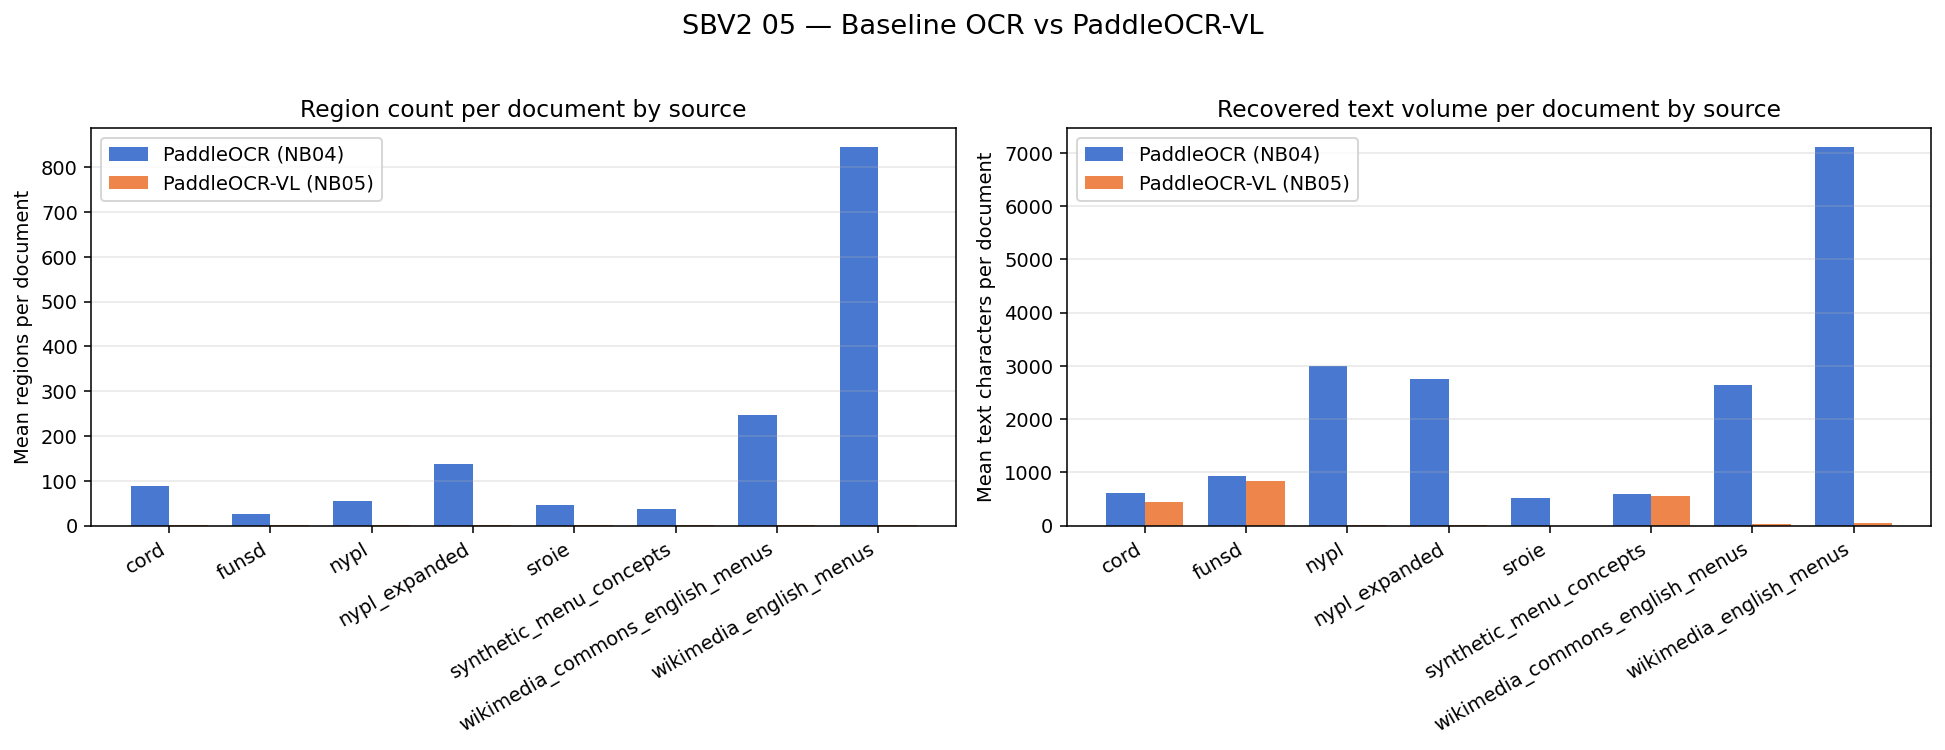

### VL Overlay Contact Sheet

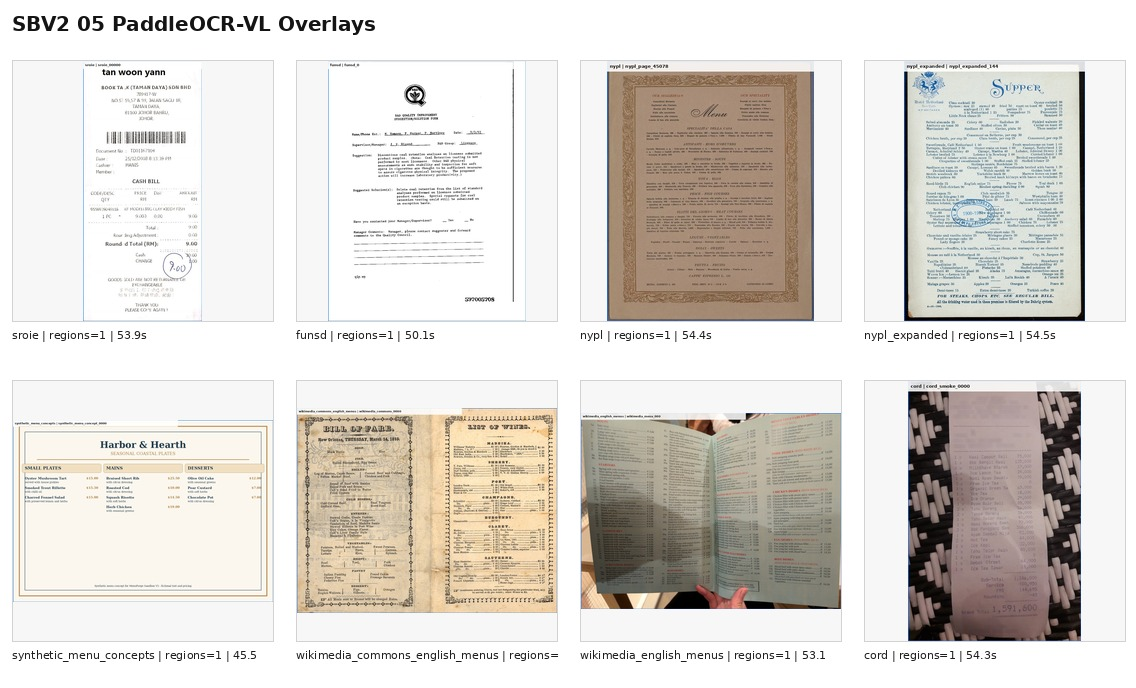

In [7]:
if summary.get("init_only"):
    overlay_msg = """### Overlay skipped

`INIT_ONLY` is `True`, so PaddleOCR-VL only loaded the model and did not predict any regions. Set `INIT_ONLY = False` in the controls cell, then rerun from the run cell to create a VL overlay and the bar chart comparison.
"""
    display(Markdown(overlay_msg))
else:
    comparison_fig = summary.get("comparison_figure")
    if comparison_fig and (ROOT / comparison_fig).exists():
        display(Markdown("### Headline figure — Baseline OCR vs PaddleOCR-VL"))
        display(Image(filename=str(ROOT / comparison_fig)))
    else:
        display(Markdown("_Comparison figure not produced. Check `ok_rows`, `failure_rows`, and the failure table above._"))

    contact_sheet = summary.get("overlay_contact_sheet")
    if contact_sheet and (ROOT / contact_sheet).exists():
        display(Markdown("### VL Overlay Contact Sheet"))
        display(Image(filename=str(ROOT / contact_sheet)))
    else:
        display(Markdown("_VL overlay contact sheet not produced. This means no successful VL document produced drawable regions._"))

## Handoff to Notebook 06

Notebook 06 should read **both** OCR and VL outputs and decide per-region which extraction to keep:

- `data/interim/sandbox_v2/ocr_outputs/sbv2_04_ocr_text_regions.csv` (Tier 1 — PaddleOCR baseline)
- `data/interim/sandbox_v2/vl_outputs/sbv2_05_vl_text_regions.csv` (Tier 2 — PaddleOCR-VL)
- `data/interim/sandbox_v2/vl_outputs/markdown/*.md` (full-document markdown from VL, useful as a fallback when per-region recovery is sparse)

The expected story for the horizon scan is: VL recovers the antique-menu material that PaddleOCR's DB detector silently dropped (NYPL bottom-half case). NB07 quantifies the lift; NB08 turns it into a readiness gate.